# 24: Where Is Causal Gain Created?

V1 and V2 are kept inconclusive, V4 resolves the original extreme-FCP local-gain claim, and V5 shows the selector-mediated redistribution pathway.


In [1]:
from pathlib import Path
import json
import math
import os
import random
import sys
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG_DIR = ROOT / "notebooks" / "generated-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT / "notebooks" / "_shared"))

from digital_crystal import (
    CrystalParams,
    advance_one_step,
    attachment_probability,
    axial_to_xy,
    cell_keyed_uniform,
    frontier,
    hex_distance,
    initial_state,
    neighbors,
    run_crystal,
)

NOTEBOOK_PROFILE = os.environ.get("NOTEBOOK_PROFILE", "quick")
RUN_CANONICAL = os.environ.get("RUN_CANONICAL", "0") in {"1", "true", "True"}

def load_json(path):
    return json.loads((ROOT / path).read_text(encoding="utf-8"))

def mean_of(summary, key="mean"):
    return summary[key] if isinstance(summary, dict) and key in summary else summary

def audit(label, observed, source="canonical research artifact"):
    return {"label": label, "source": source, "observed": observed}

def plot_cells(ax, occupied, lost=None, selected=None, title=""):
    lost = lost or set()
    selected = selected or set()
    for cells, color, size, alpha in [(occupied, "#253494", 18, .85), (lost, "#b2182b", 30, .9), (selected, "#fdae61", 45, .95)]:
        if cells:
            xy = np.array([axial_to_xy(c) for c in cells])
            ax.scatter(xy[:,0], xy[:,1], s=size, c=color, alpha=alpha)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(title)


## FCP identity and early inconclusive screens


In [2]:
before = {(0,0), (1,0), (1,-1)}
x = (0,-1)
frontier_before = frontier(before, 3)
after = before | {x}
frontier_after = frontier(after, 3)
promoted = len(frontier_after - frontier_before)
fcp = len(frontier_after) - len(frontier_before)
assert fcp == promoted - 1
v1 = load_json("research/digital-life/ch24-frontier-creation-causal-gain-v1/stage-04-verdict.json")
v2 = load_json("research/digital-life/ch24-local-frontier-motifs-v2/stage-04-verdict.json")
v3tests = load_json("research/digital-life/ch24-local-process-history-v3/stage-02-primary-history-tests.json")
v3 = load_json("research/digital-life/ch24-local-process-history-v3/stage-04-verdict.json")
audit("FCP and early screens", {
    "assertion_fcp_equals_promoted_minus_one": fcp,
    "v1_status": v1["overall_status"],
    "v2_status": v2["overall_status"],
    "v3_status": v3["overall_status"],
    "v3_turnover_difference": sum(v3tests["history_component_differences"][k]["mean"] for k in ["recent_attachments", "recent_losses"]),
    "v3_transient_gain_difference": v3tests["H1_recent_turnover_predicts_transient_gain"]["group_gain_difference_high_minus_low"]["mean"],
}, source="quick recomputed + canonical research artifact")


{'label': 'FCP and early screens',
 'source': 'quick recomputed + canonical research artifact',
 'observed': {'assertion_fcp_equals_promoted_minus_one': 1,
  'v1_status': 'FRONTIER_GEOMETRY_CONTRAST_SUPPORTED_GAIN_LINK_FAILED',
  'v2_status': 'LOCAL_MOTIF_HYPOTHESIS_FAILED',
  'v3_status': 'RECENT_PROCESS_HISTORY_GAIN_LINK_FAILED',
  'v3_turnover_difference': 7.734375,
  'v3_transient_gain_difference': -0.06510416666666667}}

## V4 and V5 accounting


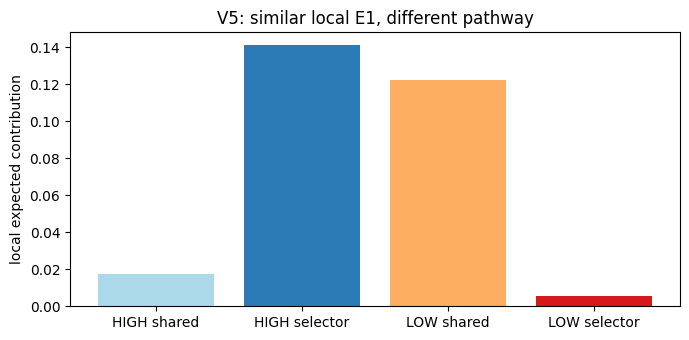

{'label': 'V4/V5',
 'source': 'canonical research artifact',
 'observed': {'v4_groups': 384,
  'v4_usable': 275,
  'v4_coverage': 0.7161458333333334,
  'v4_delta_E1_mean': -0.002580487051053025,
  'v4_delta_E1_ci': [-0.0395016984122971, 0.03327085181727841],
  'v4_status': 'EXTREME_FCP_EXPECTED_EFFECT_BOUNDED_BELOW_SEI',
  'v5_pairs': 467,
  'v5_n_distribution': {'1': 467},
  'baseline_p_by_n': {'1': {'interventions': 934,
    'pairs': 467,
    'high_baseline_p_mean': 0.38041146423796446,
    'low_baseline_p_mean': 0.38041146423796446,
    'raw_pair_baseline_p_difference': {'n': 467,
     'mean': 3.358008613025768e-17,
     'sd': 5.275744418057095e-16,
     'se': 2.4413233661889024e-17,
     'ci95_low': -1.5038232377183094e-17,
     'ci95_high': 8.166201476632575e-17,
     'half_width': 4.835012357175443e-17,
     'achieved_mde80_one_sided': 6.070289176439476e-17}}},
  'far_high': -0.11703353990264478,
  'far_low': 0.0628899107580078,
  'v5_status': 'FIXED_BUDGET_SELECTOR_ACCOUNTING_SU

In [3]:
v4support = load_json("research/digital-life/ch24-frontier-creation-causal-gain-v4/stage-01-design-support.json")
v4analysis = load_json("research/digital-life/ch24-frontier-creation-causal-gain-v4/stage-03-primary-analysis.json")
v4 = load_json("research/digital-life/ch24-frontier-creation-causal-gain-v4/stage-05-verdict.json")
v5support = load_json("research/digital-life/ch24-causal-accounting-v5/stage-01-run-and-support.json")
v5acc = load_json("research/digital-life/ch24-causal-accounting-v5/stage-02-exact-accounting.json")
v5scope = load_json("research/digital-life/ch24-causal-accounting-v5/stage-05-scope-and-baseline-p.json")
v5 = load_json("research/digital-life/ch24-causal-accounting-v5/stage-06-verdict.json")
comp = v5acc["shared_vs_swap_components"]
absE = v5acc["absolute_E1"]
assert comp["shared_shift_far"]["high"]["mean"] == 0
assert comp["shared_shift_far"]["low"]["mean"] == 0
for region in ["local", "far", "global"]:
    for level in ["high", "low"]:
        shared = comp[f"shared_shift_{region}"][level]["mean"]
        swap = comp[f"swap_total_{region}"][level]["mean"]
        total = absE[region][level]["mean"]
        assert abs((shared + swap) - total) < 1e-12
labels = ["HIGH shared", "HIGH selector", "LOW shared", "LOW selector"]
vals = [comp["shared_shift_local"]["high"]["mean"], comp["swap_total_local"]["high"]["mean"], comp["shared_shift_local"]["low"]["mean"], comp["swap_total_local"]["low"]["mean"]]
fig, ax = plt.subplots(figsize=(7,3.5))
ax.bar(labels, vals, color=["#abd9e9", "#2c7bb6", "#fdae61", "#d7191c"]); ax.set(title="V5: similar local E1, different pathway", ylabel="local expected contribution")
fig.tight_layout(); fig.savefig(FIG_DIR / "ch24-v5-accounting-audit.png", bbox_inches="tight"); plt.show()
audit("V4/V5", {
    "v4_groups": v4support["requested_groups"],
    "v4_usable": v4support["groups_with_extreme_pairs"],
    "v4_coverage": v4support["coverage_fraction"],
    "v4_delta_E1_mean": v4analysis["H1_primary_exact_expected_lag1_gain"]["summary"]["mean"],
    "v4_delta_E1_ci": [v4analysis["H1_primary_exact_expected_lag1_gain"]["summary"]["ci95_low"], v4analysis["H1_primary_exact_expected_lag1_gain"]["summary"]["ci95_high"]],
    "v4_status": v4["overall_status"],
    "v5_pairs": v5support["total_pairs"],
    "v5_n_distribution": v5support["occupied_neighbor_pair_distribution"],
    "baseline_p_by_n": v5scope["baseline_p_by_n"],
    "far_high": absE["far"]["high"]["mean"],
    "far_low": absE["far"]["low"]["mean"],
    "v5_status": v5["overall_status"],
}, source="canonical research artifact")


## Bounded claim

Extreme FCP did not produce a scientifically meaningful +0.10 local E1 difference. V5 exposes why similar local effect sizes can have different computational pathways, and why far-field effects arise through finite global selection rather than spatial signal travel.

## Provenance

Current local book chapter: `content/books/digital-life/24-where-is-causal-gain-created/index.md` (local working tree authority)

Research scripts: `ch24_digital_crystal_frontier_creation_causal_gain_v1.py`, `ch24_digital_crystal_local_frontier_motifs_v2.py`, `ch24_digital_crystal_local_process_history_v3.py`, `ch24_digital_crystal_frontier_creation_causal_gain_v4.py`, `ch24_digital_crystal_causal_accounting_v5.py`

Canonical artifacts: `research/digital-life/ch24-frontier-creation-causal-gain-v1/`, `v4/`, `ch24-local-frontier-motifs-v2/`, `ch24-local-process-history-v3/`, `ch24-causal-accounting-v5/`

Notebook figures: `ch24-v5-accounting-audit.png`

Execution mode: quick assertion check + canonical-artifact-audit

## Claim Ledger

ASSERTION: FCP equals promoted frontier minus one for a frontier intervention; shared far-cell probability shift is zero at lag 1; decomposition sums exactly to E1.

INCONCLUSIVE: V1 FCP screen; V2 exact motifs.

FAILED / BOUNDED NEGATIVE: V4 extreme FCP does not yield a meaningful +0.10 local E1 contrast.

SUPPORTED: V5 selector-mediated far-field redistribution in the single-contact frontier regime.

UNRESOLVED: V4 model-implied divergence and finite-horizon transient gain.
